# Working with Imbalanced Data

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [29]:
np.random.seed(42)
n_samples1 = 25
n_samples2 = 375
centers = [(0,0), (2,2)]
cluster_std = [1.5, 1.5]

X, y = make_blobs(n_samples=[n_samples1, n_samples2],
                  centers=centers,
                  cluster_std=cluster_std
                 )

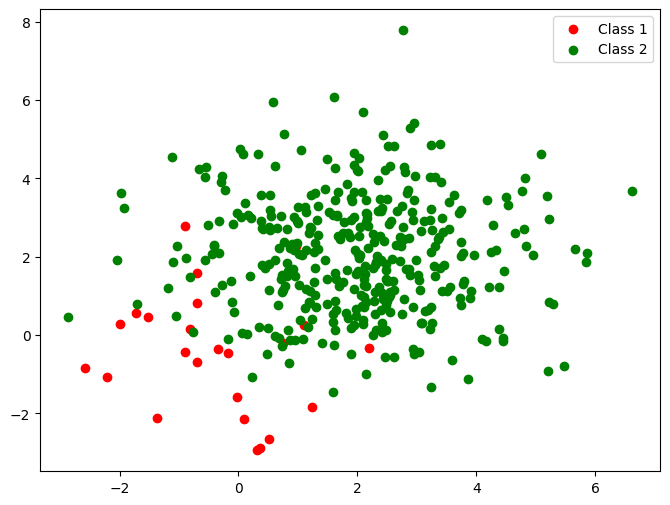

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:,0], X[y == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X[y == 1][:,0], X[y == 1][:,1] ,color='green', label='Class 2')
plt.legend()
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [32]:
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [34]:
y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC_AUC_SCORE : ", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.97      0.99      0.98        76

    accuracy                           0.96        80
   macro avg       0.82      0.74      0.78        80
weighted avg       0.96      0.96      0.96        80

ROC_AUC_SCORE :  0.875


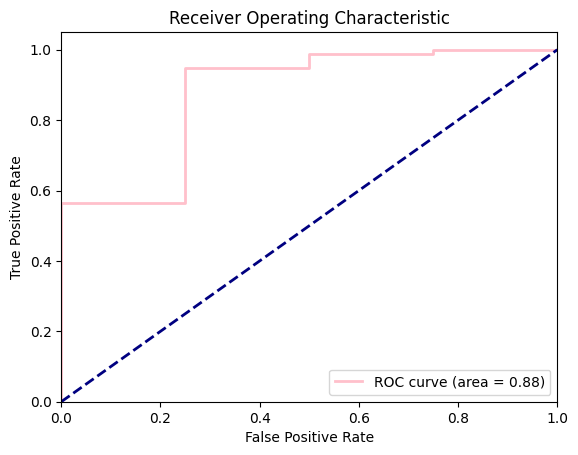

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='pink', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

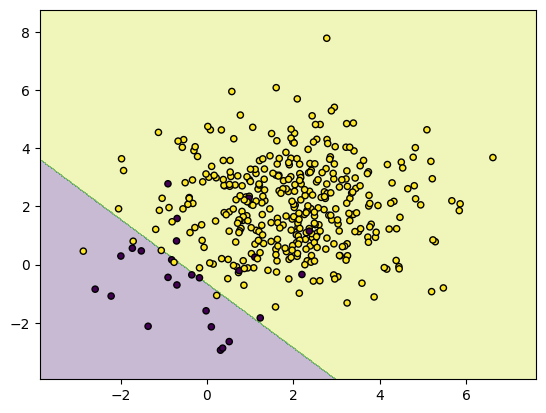

In [36]:
def plot_decision_boundry(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 
    y_mix, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_mix, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.show()

plot_decision_boundry(X, y, lr)

# Random Undersampling

In [97]:
from imblearn.under_sampling import RandomUnderSampler
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
rus = RandomUnderSampler(random_state=42)
X_resample_under, y_resample_under = rus.fit_resample(X_train, y_train)

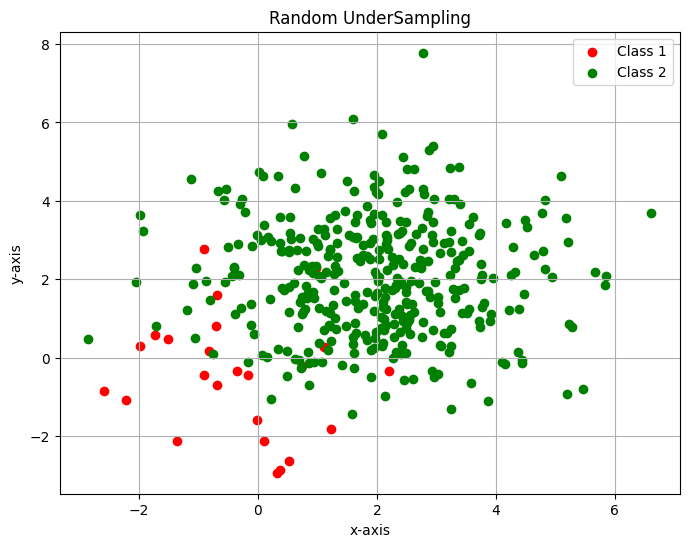

In [99]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:,0], X[y == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X[y == 1][:,0], X[y == 1][:,1] ,color='green', label='Class 2')
plt.title('Random UnderSampling')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()
plt.grid(True)
plt.show()

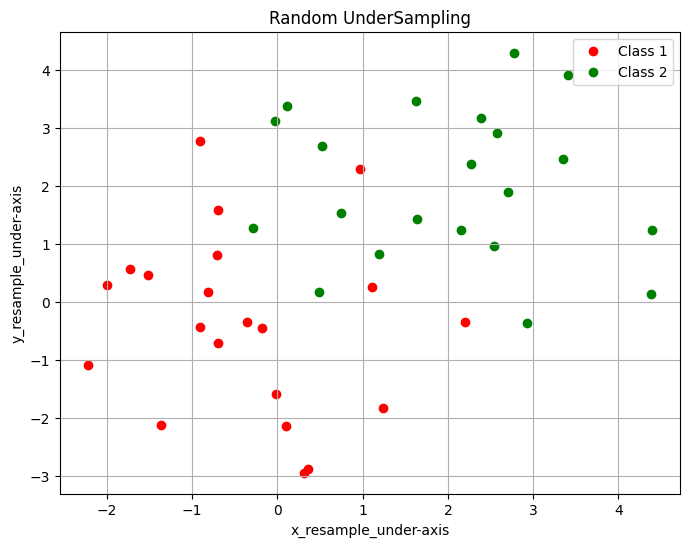

In [100]:
plt.figure(figsize=(8, 6))
plt.scatter(X_resample_under[y_resample_under == 0][:,0], X_resample_under[y_resample_under == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X_resample_under[y_resample_under == 1][:,0], X_resample_under[y_resample_under == 1][:,1] ,color='green', label='Class 2')
plt.title('Random UnderSampling')
plt.xlabel('x_resample_under-axis')
plt.ylabel('y_resample_under-axis')
plt.legend()
plt.grid(True)
plt.show()

In [101]:
print(X_train.shape)
print(y_train.shape)
print(X_resample_under.shape)
print(y_resample_under.shape)

(320, 2)
(320,)
(42, 2)
(42,)


In [102]:
print('Before Resample')
print(pd.Series(y_train).value_counts())
print('After Resample')
print(pd.Series(y_resample_under).value_counts())

Before Resample
1    299
0     21
Name: count, dtype: int64
After Resample
0    21
1    21
Name: count, dtype: int64


In [103]:
lr_rus = LogisticRegression()
lr_rus.fit(X_resample_under, y_resample_under)

LogisticRegression()

In [104]:
y_pred_rus = lr_rus.predict(X_test)
y_proba_rus = lr_rus.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_rus))
print("ROC_AUC_SCORE : ", roc_auc_score(y_test, y_proba_rus))

              precision    recall  f1-score   support

           0       0.23      0.75      0.35         4
           1       0.99      0.87      0.92        76

    accuracy                           0.86        80
   macro avg       0.61      0.81      0.64        80
weighted avg       0.95      0.86      0.89        80

ROC_AUC_SCORE :  0.8717105263157895


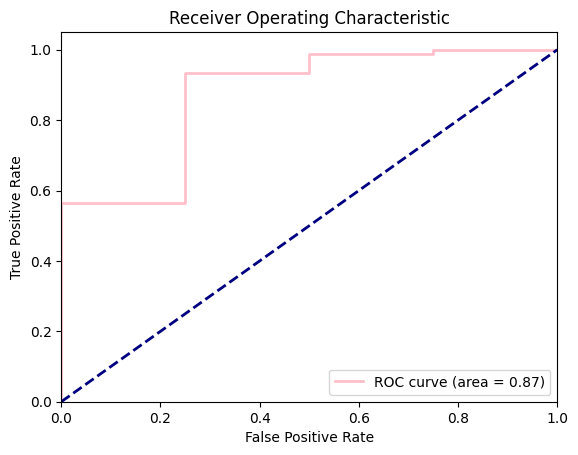

In [105]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rus)
plt.figure()
plt.plot(fpr, tpr, color='pink', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_rus))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

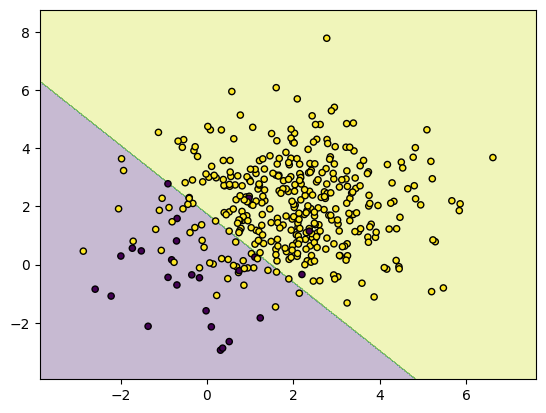

In [127]:
def plot_decision_boundry_under(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 
    y_mix, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_mix, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.show()

plot_decision_boundry_under(X, y, lr_rus)

# Random Oversampling

In [106]:
from imblearn.over_sampling import RandomOverSampler
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
ros = RandomOverSampler(random_state=42)
X_resample_over, y_resample_over = ros.fit_resample(X_train, y_train)

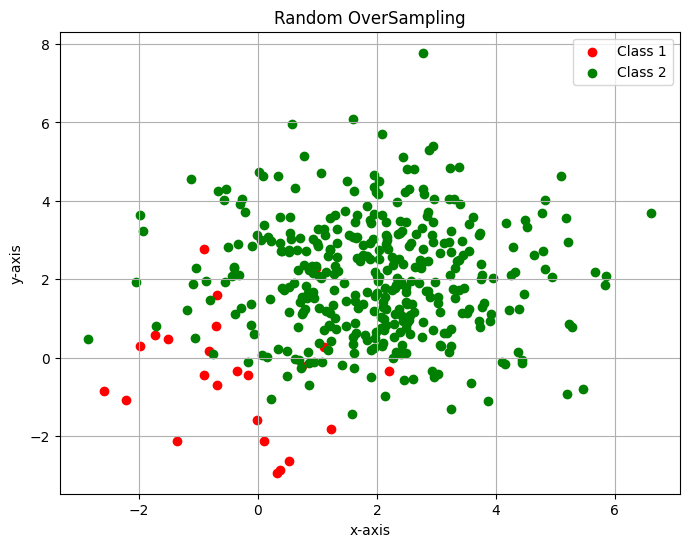

In [108]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:,0], X[y == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X[y == 1][:,0], X[y == 1][:,1] ,color='green', label='Class 2')
plt.title('Random OverSampling')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()
plt.grid(True)
plt.show()

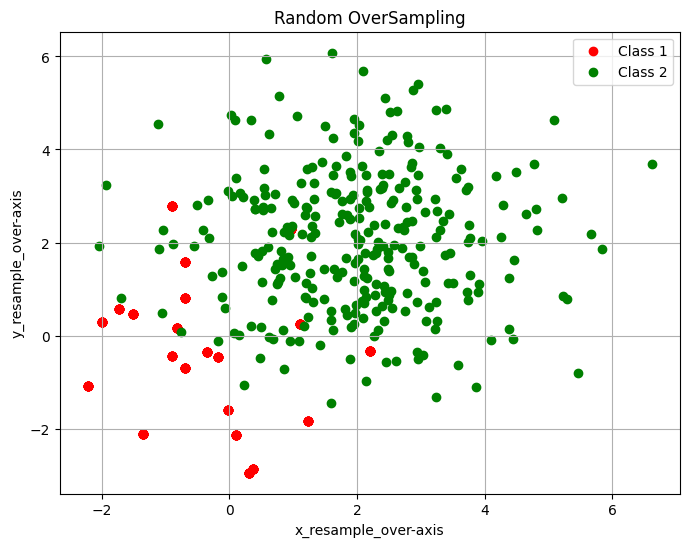

In [109]:
plt.figure(figsize=(8, 6))
plt.scatter(X_resample_over[y_resample_over == 0][:,0], X_resample_over[y_resample_over == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X_resample_over[y_resample_over == 1][:,0], X_resample_over[y_resample_over == 1][:,1] ,color='green', label='Class 2')
plt.title('Random OverSampling')
plt.xlabel('x_resample_over-axis')
plt.ylabel('y_resample_over-axis')
plt.legend()
plt.grid(True)
plt.show()

In [110]:
print(X_train.shape)
print(y_train.shape)
print(X_resample_over.shape)
print(y_resample_over.shape)

(320, 2)
(320,)
(598, 2)
(598,)


In [111]:
print('Before Resample')
print(pd.Series(y_train).value_counts())
print('After Resample')
print(pd.Series(y_resample_over).value_counts())

Before Resample
1    299
0     21
Name: count, dtype: int64
After Resample
1    299
0    299
Name: count, dtype: int64


In [112]:
lr_ros = LogisticRegression()
lr_ros.fit(X_resample_over, y_resample_over)

LogisticRegression()

In [113]:
y_pred_ros = lr_ros.predict(X_test)
y_proba_ros = lr_ros.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_ros))
print("ROC_AUC_SCORE : ", roc_auc_score(y_test, y_proba_ros))

              precision    recall  f1-score   support

           0       0.23      0.75      0.35         4
           1       0.99      0.87      0.92        76

    accuracy                           0.86        80
   macro avg       0.61      0.81      0.64        80
weighted avg       0.95      0.86      0.89        80

ROC_AUC_SCORE :  0.8717105263157895


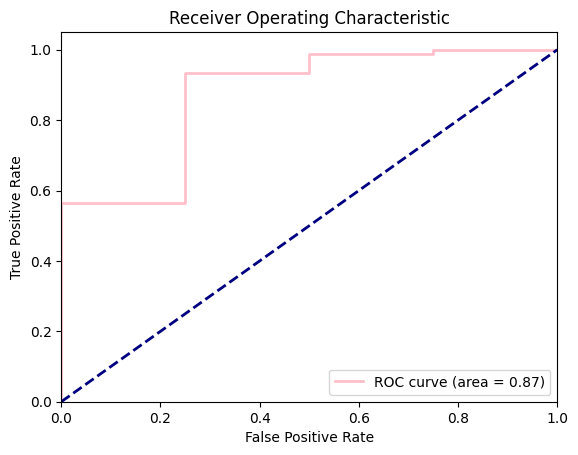

In [114]:
fpr, tpr, _ = roc_curve(y_test, y_proba_ros)
plt.figure()
plt.plot(fpr, tpr, color='pink', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_ros))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

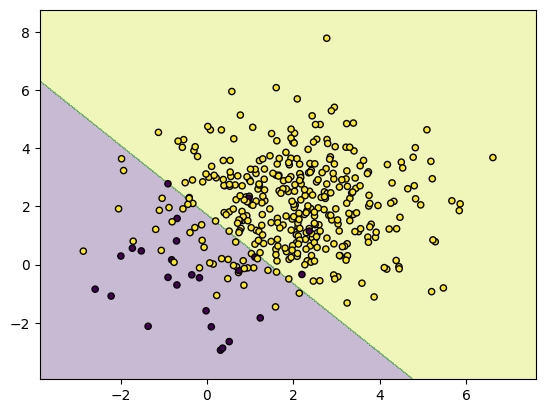

In [128]:
def plot_decision_boundry_over(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 
    y_mix, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_mix, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.show()

plot_decision_boundry_over(X, y, lr_ros)

# SMOTE

In [116]:
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
smote = SMOTE(random_state=42)
X_resample_smote, y_resample_smote = smote.fit_resample(X_train, y_train)

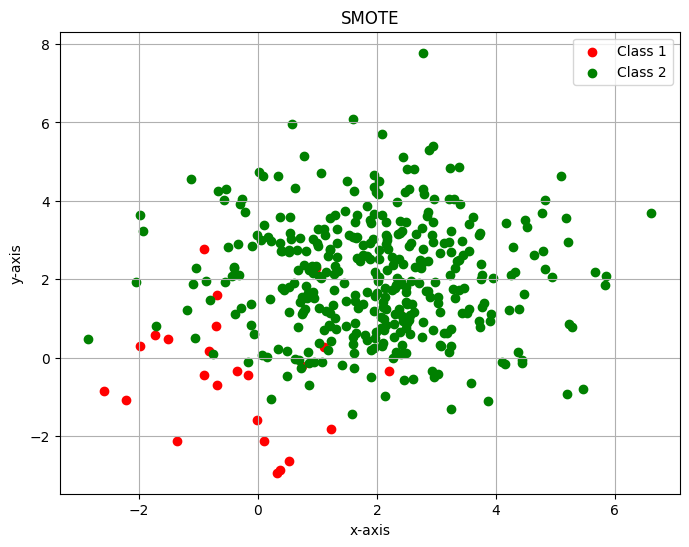

In [118]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:,0], X[y == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X[y == 1][:,0], X[y == 1][:,1] ,color='green', label='Class 2')
plt.title('SMOTE')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()
plt.grid(True)
plt.show()

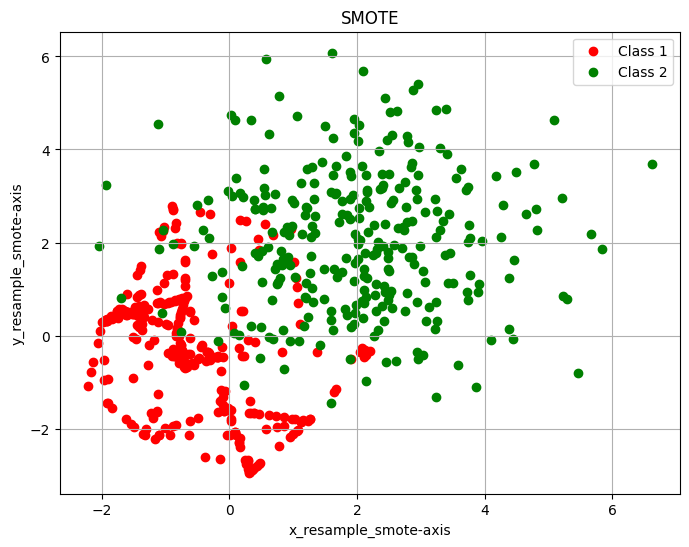

In [119]:
plt.figure(figsize=(8, 6))
plt.scatter(X_resample_smote[y_resample_smote == 0][:,0], X_resample_smote[y_resample_smote == 0][:,1] ,color='red', label='Class 1')
plt.scatter(X_resample_smote[y_resample_smote == 1][:,0], X_resample_smote[y_resample_smote == 1][:,1] ,color='green', label='Class 2')
plt.title('SMOTE')
plt.xlabel('x_resample_smote-axis')
plt.ylabel('y_resample_smote-axis')
plt.legend()
plt.grid(True)
plt.show()

In [120]:
print(X_train.shape)
print(y_train.shape)
print(X_resample_smote.shape)
print(y_resample_smote.shape)

(320, 2)
(320,)
(598, 2)
(598,)


In [121]:
print('Before Resample')
print(pd.Series(y_train).value_counts())
print('After Resample')
print(pd.Series(y_resample_smote).value_counts())

Before Resample
1    299
0     21
Name: count, dtype: int64
After Resample
1    299
0    299
Name: count, dtype: int64


In [122]:
lr_smote = LogisticRegression()
lr_smote.fit(X_resample_smote, y_resample_smote)

LogisticRegression()

In [123]:
y_pred_smote = lr_ros.predict(X_test)
y_proba_smote = lr_ros.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_smote))
print("ROC_AUC_SCORE : ", roc_auc_score(y_test, y_proba_smote))

              precision    recall  f1-score   support

           0       0.23      0.75      0.35         4
           1       0.99      0.87      0.92        76

    accuracy                           0.86        80
   macro avg       0.61      0.81      0.64        80
weighted avg       0.95      0.86      0.89        80

ROC_AUC_SCORE :  0.8717105263157895


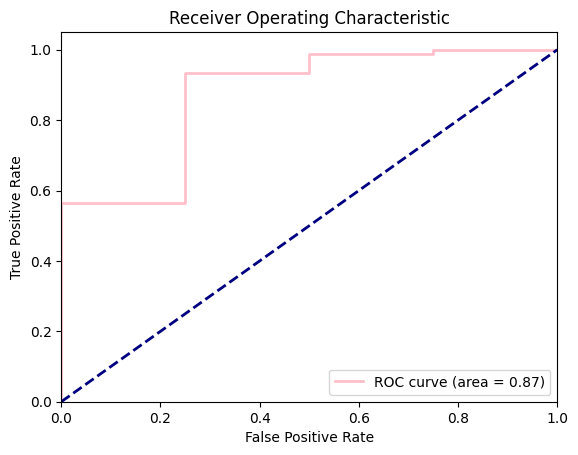

In [124]:
fpr, tpr, _ = roc_curve(y_test, y_proba_smote)
plt.figure()
plt.plot(fpr, tpr, color='pink', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_smote))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

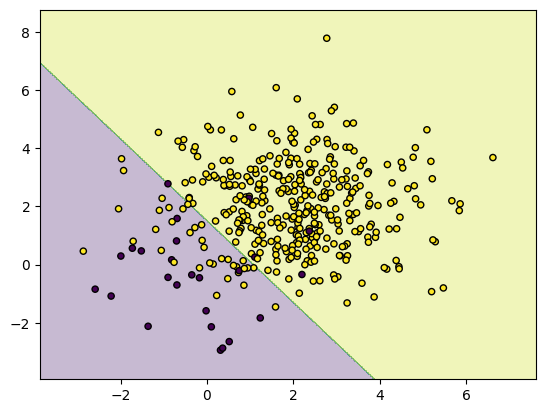

In [130]:
def plot_decision_boundry_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 
    y_mix, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_mix, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.show()

plot_decision_boundry_smote(X, y, lr_smote)

# Balanced Random Forest

In [132]:
from imblearn.ensemble import BalancedRandomForestClassifier
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [137]:
brf = BalancedRandomForestClassifier(random_state=42)
brf.fit(X_train, y_train)

C:\Users\khand\AppData\Roaming\Python\Python312\site-packages\imblearn\ensemble\_forest.py:546: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\khand\AppData\Roaming\Python\Python312\site-packages\imblearn\ensemble\_forest.py:558: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(


BalancedRandomForestClassifier(random_state=42)

In [139]:
y_pred_brf = brf.predict(X_test)
y_proba_brf = brf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_brf))
print("ROC_AUC_SCORE : ", roc_auc_score(y_test, y_proba_brf))

              precision    recall  f1-score   support

           0       0.16      0.75      0.26         4
           1       0.98      0.79      0.88        76

    accuracy                           0.79        80
   macro avg       0.57      0.77      0.57        80
weighted avg       0.94      0.79      0.85        80

ROC_AUC_SCORE :  0.8256578947368421


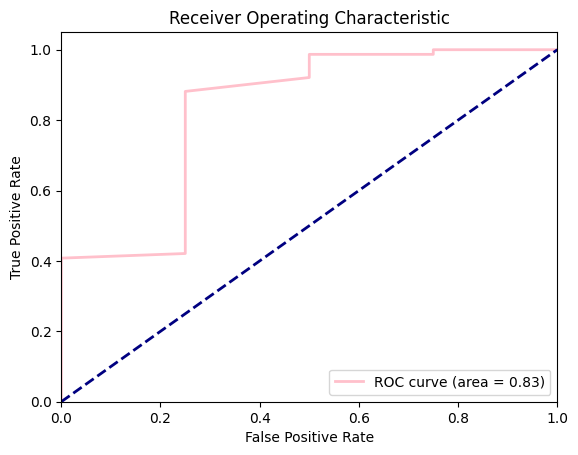

In [140]:
fpr, tpr, _ = roc_curve(y_test, y_proba_brf)
plt.figure()
plt.plot(fpr, tpr, color='pink', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_brf))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

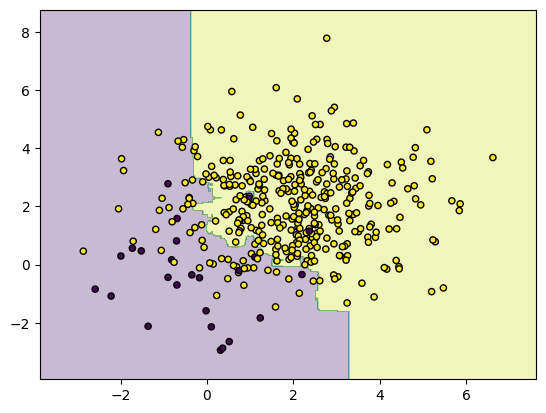

In [142]:
def plot_decision_boundry_brf(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 
    y_mix, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_mix, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.show()

plot_decision_boundry_brf(X, y, brf)

# Class Weights

In [143]:
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
lr_cw = LogisticRegression(class_weight={0:50, 1:1}, solver='liblinear')
lr_cw.fit(X_train, y_train)

LogisticRegression(class_weight={0: 50, 1: 1}, solver='liblinear')

In [146]:
y_pred_cw = brf.predict(X_test)
y_proba_cw = brf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred_cw))
print("ROC_AUC_SCORE : ", roc_auc_score(y_test, y_proba_cw))

              precision    recall  f1-score   support

           0       0.16      0.75      0.26         4
           1       0.98      0.79      0.88        76

    accuracy                           0.79        80
   macro avg       0.57      0.77      0.57        80
weighted avg       0.94      0.79      0.85        80

ROC_AUC_SCORE :  0.8256578947368421


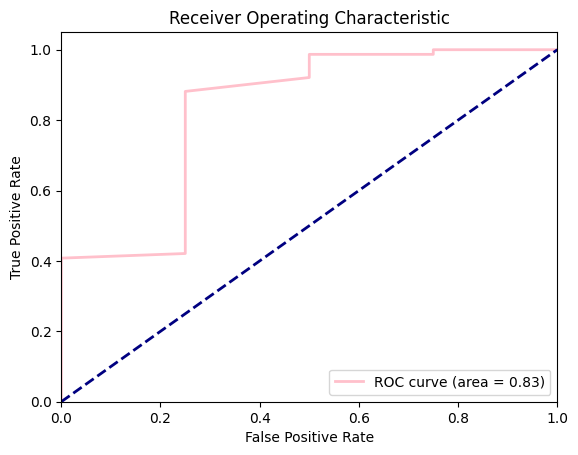

In [147]:
fpr, tpr, _ = roc_curve(y_test, y_proba_cw)
plt.figure()
plt.plot(fpr, tpr, color='pink', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_cw))
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

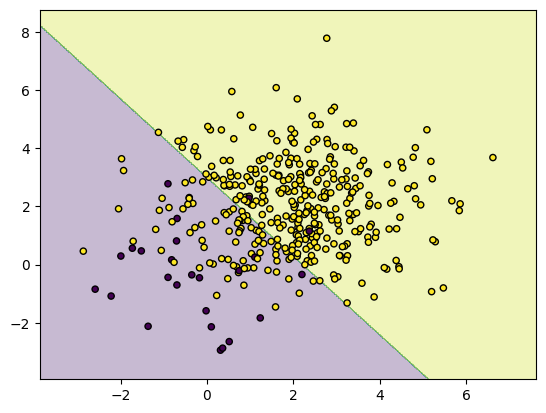

In [148]:
def plot_decision_boundry_cw(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1 
    y_mix, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_mix, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.show()

plot_decision_boundry_cw(X, y, lr_cw)